## Importing and Library Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Load Dataset

In [12]:
downloads_dir = Path.home() / "Downloads"
file_path = downloads_dir / "C:/Users/samal/Downloads/synthetic_online_retail_engineered.csv"
df = pd.read_csv("C:/Users/samal/Downloads/synthetic_online_retail_engineered.csv")
df.head()
df.info()
df[['total_spend', 'recency_days', 'purchase_frequency', 'average_order_value', 'customer_lifetime_value']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1000 non-null   int64  
 1   order_date               1000 non-null   object 
 2   product_id               1000 non-null   int64  
 3   category_id              1000 non-null   int64  
 4   category_name            1000 non-null   object 
 5   product_name             1000 non-null   object 
 6   quantity                 1000 non-null   int64  
 7   price                    1000 non-null   float64
 8   payment_method           1000 non-null   object 
 9   city                     1000 non-null   object 
 10  review_score             799 non-null    float64
 11  gender                   897 non-null    object 
 12  age                      1000 non-null   int64  
 13  total_spend              1000 non-null   float64
 14  recency_days             

,total_spend,recency_days,purchase_frequency,average_order_value,customer_lifetime_value
count,1000.000000,1000.000000,1000.0,1000.000000,1000.000000
mean,737.326880,186.207000,1.0,737.326880,737.326880
std,566.404843,104.826011,0.0,566.404843,566.404843
min,20.840000,1.000000,1.0,20.840000,20.840000
25%,285.837500,93.000000,1.0,285.837500,285.837500
50%,592.785000,187.000000,1.0,592.785000,592.785000
75%,1081.040000,277.000000,1.0,1081.040000,1081.040000
max,2437.650000,366.000000,1.0,2437.650000,2437.650000


## Data Preprocessing

In [13]:
customer_df = df.groupby('customer_id').agg({
    'recency_days': 'min',
    'purchase_frequency': 'first',
    'average_order_value': 'first',
    'customer_lifetime_value': 'first'
}).reset_index()
features = ['recency_days', 'purchase_frequency', 'average_order_value', 'customer_lifetime_value']
customer_log = np.log1p(customer_df[features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_log)

print("Preprocessed Data Matrix Shape:", X_scaled.shape)

Preprocessed Data Matrix Shape: (1000, 4)


## Data Clustering using KMeans

In [14]:
silhouette_scores = []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_df['cluster'] = kmeans.fit_predict(X_scaled)
segment_map = {0: 'Moderate Buyers', 1: 'High-Value Loyalists', 2: 'Low-Spend / At-Risk'}
customer_df['segment_name'] = customer_df['cluster'].map(segment_map)
customer_df.head()

,customer_id,recency_days,purchase_frequency,average_order_value,customer_lifetime_value,cluster,segment_name
0,10201,157,1,624.84,624.84,1,High-Value Loyalists
1,10211,240,1,65.02,65.02,0,Moderate Buyers
2,10254,191,1,70.93,70.93,0,Moderate Buyers
3,10299,113,1,815.76,815.76,1,High-Value Loyalists
4,10403,321,1,1319.35,1319.35,1,High-Value Loyalists


## Visualiization (Elbow & Silhouette Plot)

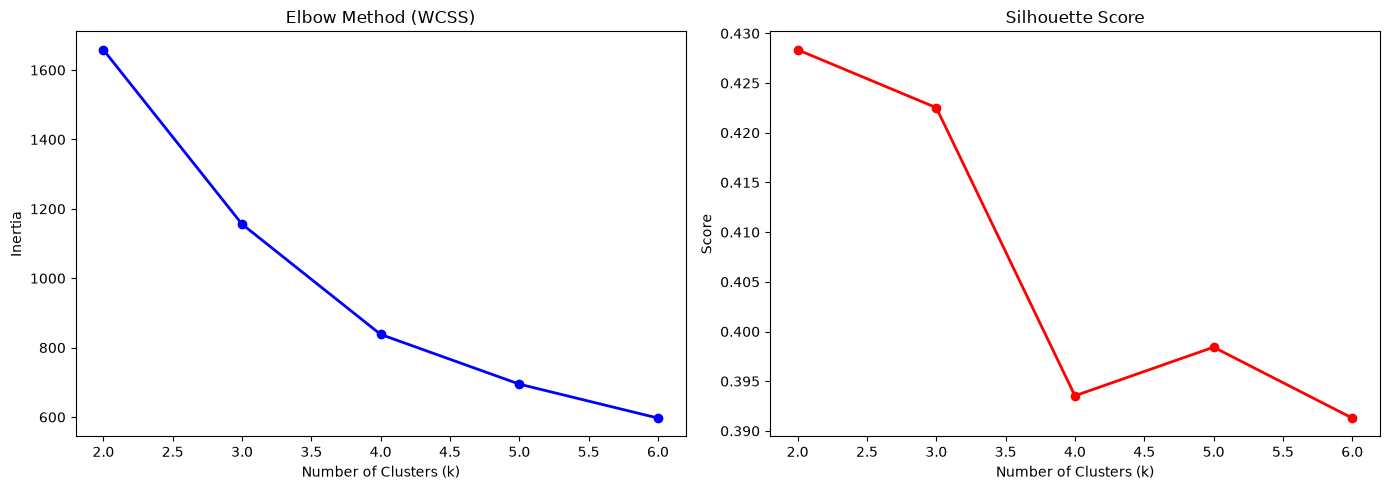

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
wcss = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in k_range]
ax[0].plot(k_range, wcss, 'bo-', linewidth=2)
ax[0].set_title('Elbow Method (WCSS)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2)
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

## Visualization (Cluster Scatter Plot)

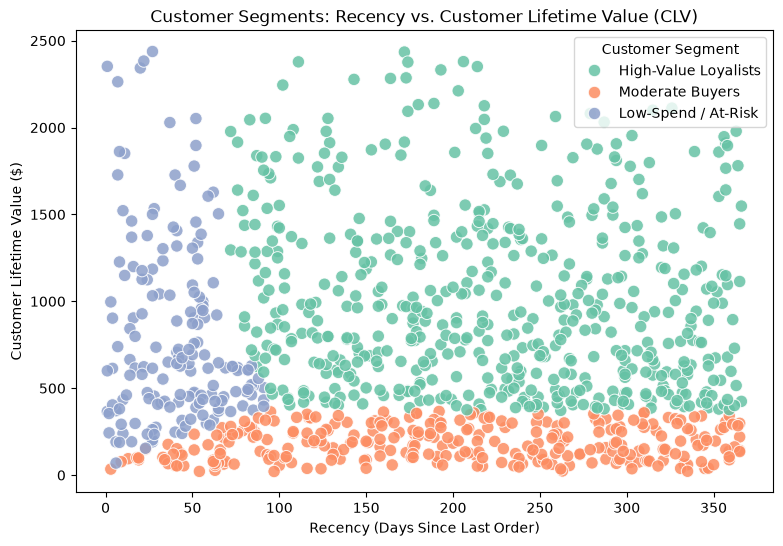

In [16]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=customer_df,
    x='recency_days',
    y='customer_lifetime_value',
    hue='segment_name',
    palette='Set2',
    s=80,
    alpha=0.85
)
plt.title('Customer Segments: Recency vs. Customer Lifetime Value (CLV)')
plt.xlabel('Recency (Days Since Last Order)')
plt.ylabel('Customer Lifetime Value ($)')
plt.legend(title='Customer Segment')
plt.show()

## Visualization (Comparison Plotting)

C:\Users\samal\AppData\Local\Temp\ipykernel_6540\460568753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_df, x='segment_name', y='customer_lifetime_value', ax=axes[0], palette='Set2')
C:\Users\samal\AppData\Local\Temp\ipykernel_6540\460568753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_df, x='segment_name', y='average_order_value', ax=axes[1], palette='Set2')
C:\Users\samal\AppData\Local\Temp\ipykernel_6540\460568753.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_df, x='segment_nam

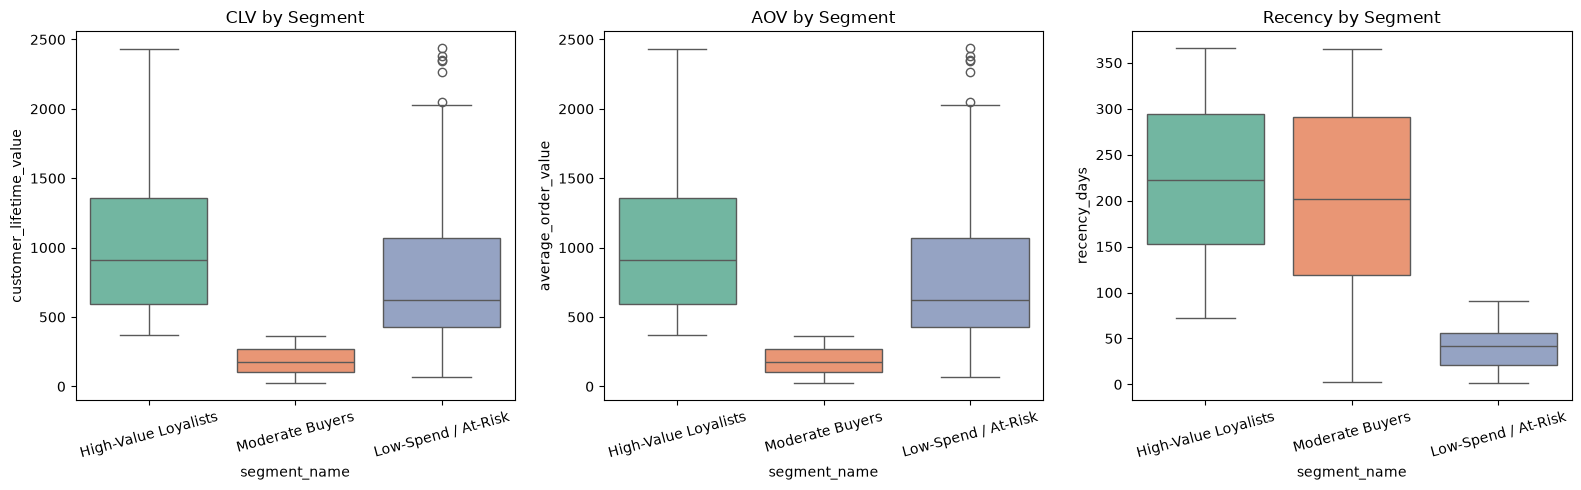

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=customer_df, x='segment_name', y='customer_lifetime_value', ax=axes[0], palette='Set2')
axes[0].set_title('CLV by Segment')
axes[0].tick_params(axis='x', rotation=15)
sns.boxplot(data=customer_df, x='segment_name', y='average_order_value', ax=axes[1], palette='Set2')
axes[1].set_title('AOV by Segment')
axes[1].tick_params(axis='x', rotation=15)
sns.boxplot(data=customer_df, x='segment_name', y='recency_days', ax=axes[2], palette='Set2')
axes[2].set_title('Recency by Segment')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()